In [1]:
#importing Libraries 
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

c:\Users\vshru\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
#loading data
dataset = load_dataset('lukebarousse/data_jobs')
df =dataset['train'].to_pandas()

In [3]:
#Cleanup data
df['job_posted_date']= pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x:ast.literal_eval(x) if pd.notna(x)else x)

In [4]:
#This  is a filtering operation. It is used to narrow down your entire dataset so that it only includes rows related to Data Analysts.
df_DA = df[df['job_title_short']=='Data Analyst'].copy()

In [ ]:
df_DA

In [6]:
#creates a new column in dataframe 
df_DA['job_posted_month_no']=df_DA['job_posted_date'].dt.month

In [ ]:
df_DA

In [8]:
df_DA_exploded=df_DA.explode('job_skills')

In [ ]:
df_DA_exploded

In [10]:
df_DA_pivot=df_DA_exploded.pivot_table(index = 'job_posted_month_no',columns='job_skills',aggfunc='size',fill_value=0)

In [11]:
df_DA_pivot

job_skills,airflow,airtable,alteryx,angular,angular.js,ansible,apl,arch,asana,asp.net,...,webex,windows,wire,word,workfront,wrike,wsl,xamarin,yarn,zoom
job_posted_month_no,,,,,,,,,,,,,,,,,,,,,
1,197,17,551,63,2,20,2,1,29,34,...,17,228,6,1778,0,11,6,0,9,95
2,169,2,448,49,0,14,1,4,27,13,...,9,202,6,1235,4,2,5,0,4,41
3,181,4,442,34,0,23,6,1,17,13,...,8,194,8,1203,1,1,3,1,5,45
4,155,4,413,22,0,11,8,9,9,15,...,9,185,14,1177,8,2,1,0,6,26
5,128,8,310,30,0,19,9,2,8,21,...,11,122,3,957,3,4,0,0,7,18
6,164,14,393,29,0,14,9,4,16,16,...,8,157,14,1237,6,6,0,0,11,34
7,207,4,366,15,0,8,5,8,19,12,...,5,161,11,1069,0,3,0,0,6,38
8,197,3,413,21,0,12,10,3,13,12,...,9,184,11,1298,0,1,0,0,11,41
9,118,4,317,21,0,14,3,10,12,10,...,4,150,8,945,0,1,0,0,5,25


In [12]:
df_DA_pivot=df_DA_pivot.reset_index()

In [13]:
df_DA_pivot

job_skills,job_posted_month_no,airflow,airtable,alteryx,angular,angular.js,ansible,apl,arch,asana,...,webex,windows,wire,word,workfront,wrike,wsl,xamarin,yarn,zoom
0,1,197,17,551,63,2,20,2,1,29,...,17,228,6,1778,0,11,6,0,9,95
1,2,169,2,448,49,0,14,1,4,27,...,9,202,6,1235,4,2,5,0,4,41
2,3,181,4,442,34,0,23,6,1,17,...,8,194,8,1203,1,1,3,1,5,45
3,4,155,4,413,22,0,11,8,9,9,...,9,185,14,1177,8,2,1,0,6,26
4,5,128,8,310,30,0,19,9,2,8,...,11,122,3,957,3,4,0,0,7,18
5,6,164,14,393,29,0,14,9,4,16,...,8,157,14,1237,6,6,0,0,11,34
6,7,207,4,366,15,0,8,5,8,19,...,5,161,11,1069,0,3,0,0,6,38
7,8,197,3,413,21,0,12,10,3,13,...,9,184,11,1298,0,1,0,0,11,41
8,9,118,4,317,21,0,14,3,10,12,...,4,150,8,945,0,1,0,0,5,25
9,10,173,11,350,40,0,19,0,8,11,...,4,156,8,990,5,2,0,1,4,39


In [14]:
df_DA_pivot.loc['Total'] = df_DA_pivot.sum()

In [15]:
df_DA_pivot

job_skills,job_posted_month_no,airflow,airtable,alteryx,angular,angular.js,ansible,apl,arch,asana,...,webex,windows,wire,word,workfront,wrike,wsl,xamarin,yarn,zoom
0,1,197,17,551,63,2,20,2,1,29,...,17,228,6,1778,0,11,6,0,9,95
1,2,169,2,448,49,0,14,1,4,27,...,9,202,6,1235,4,2,5,0,4,41
2,3,181,4,442,34,0,23,6,1,17,...,8,194,8,1203,1,1,3,1,5,45
3,4,155,4,413,22,0,11,8,9,9,...,9,185,14,1177,8,2,1,0,6,26
4,5,128,8,310,30,0,19,9,2,8,...,11,122,3,957,3,4,0,0,7,18
5,6,164,14,393,29,0,14,9,4,16,...,8,157,14,1237,6,6,0,0,11,34
6,7,207,4,366,15,0,8,5,8,19,...,5,161,11,1069,0,3,0,0,6,38
7,8,197,3,413,21,0,12,10,3,13,...,9,184,11,1298,0,1,0,0,11,41
8,9,118,4,317,21,0,14,3,10,12,...,4,150,8,945,0,1,0,0,5,25
9,10,173,11,350,40,0,19,0,8,11,...,4,156,8,990,5,2,0,1,4,39


In [16]:
df_DA_pivot=df_DA_pivot[df_DA_pivot.loc['Total'].sort_values(ascending = False).index]

In [17]:
df_DA_pivot

job_skills,sql,excel,python,tableau,power bi,r,sas,powerpoint,word,sap,...,xamarin,mattermost,gtx,esquisse,chainer,capacitor,nuxt.js,msaccess,ovh,suse
0,11336,8170,6606,5596,4285,3607,3830,1880,1778,1251,...,0,0,0,0,0,1,1,0,0,0
1,7947,5772,4751,3936,3307,2576,2634,1291,1235,954,...,0,0,0,0,0,0,0,0,0,0
2,7868,5675,4741,4051,3176,2650,2554,1266,1203,892,...,1,0,0,0,0,0,0,0,0,1
3,7553,5496,4557,3776,3106,2399,2598,1190,1177,947,...,0,0,0,0,0,0,0,0,1,0
4,6617,4773,4070,3245,2695,2093,1940,979,957,851,...,0,0,0,0,0,0,0,1,0,0
5,7584,5724,4707,3812,3275,2442,2174,1173,1237,987,...,0,0,0,0,0,0,0,0,0,0
6,7687,5513,4831,3928,3350,2444,2118,1096,1069,996,...,0,0,1,0,0,0,0,0,0,0
7,8823,6482,5576,4533,3859,2975,2560,1332,1298,1117,...,0,0,0,0,0,0,0,0,0,0
8,6829,4886,4229,3446,3118,2146,1880,944,945,852,...,0,1,0,0,0,0,0,0,0,0
9,7474,5217,4693,3709,3340,2380,2114,955,990,872,...,1,0,0,0,0,0,0,0,0,0


In [18]:
df_DA_pivot = df_DA_pivot.drop('Total')

In [19]:
df_DA_pivot

job_skills,sql,excel,python,tableau,power bi,r,sas,powerpoint,word,sap,...,xamarin,mattermost,gtx,esquisse,chainer,capacitor,nuxt.js,msaccess,ovh,suse
0,11336,8170,6606,5596,4285,3607,3830,1880,1778,1251,...,0,0,0,0,0,1,1,0,0,0
1,7947,5772,4751,3936,3307,2576,2634,1291,1235,954,...,0,0,0,0,0,0,0,0,0,0
2,7868,5675,4741,4051,3176,2650,2554,1266,1203,892,...,1,0,0,0,0,0,0,0,0,1
3,7553,5496,4557,3776,3106,2399,2598,1190,1177,947,...,0,0,0,0,0,0,0,0,1,0
4,6617,4773,4070,3245,2695,2093,1940,979,957,851,...,0,0,0,0,0,0,0,1,0,0
5,7584,5724,4707,3812,3275,2442,2174,1173,1237,987,...,0,0,0,0,0,0,0,0,0,0
6,7687,5513,4831,3928,3350,2444,2118,1096,1069,996,...,0,0,1,0,0,0,0,0,0,0
7,8823,6482,5576,4533,3859,2975,2560,1332,1298,1117,...,0,0,0,0,0,0,0,0,0,0
8,6829,4886,4229,3446,3118,2146,1880,944,945,852,...,0,1,0,0,0,0,0,0,0,0
9,7474,5217,4693,3709,3340,2380,2114,955,990,872,...,1,0,0,0,0,0,0,0,0,0


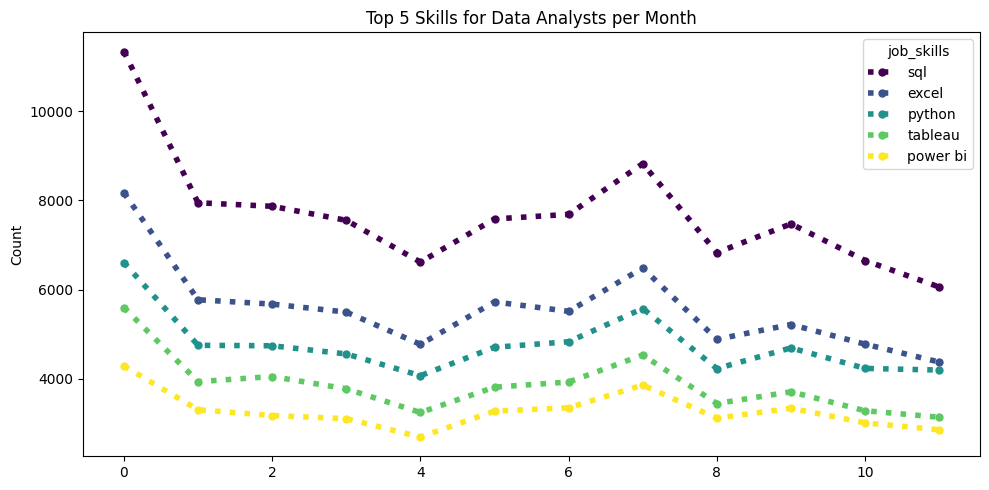

In [28]:
df_DA_pivot.iloc[:,:5].plot(kind='line',
                linewidth =4,
                linestyle=':',
                colormap='viridis',
                marker='o',
                markersize=5,
                figsize=(10,5)
                )
plt.title('Top 5 Skills for Data Analysts per Month')
plt.xlabel('')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [4]:
!pip install adjustText


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:

df=df[df['job_title_short']=='Data Analyst']

In [6]:
#Explode job skills into individual rows
df_exploded=df.explode('job_skills')

In [7]:
#Calculate the average salary and count of job postings per skill
skill_stats=df_exploded.groupby('job_skills').agg(
    skill_count =('job_skills','count'),
    median_salary = ('salary_year_avg','median')
)

In [8]:
skill_count = 20

In [9]:
skill_stats

,skill_count,median_salary
job_skills,,
airflow,2002,111175.0
airtable,88,90000.0
alteryx,4570,105000.0
angular,376,109101.0
angular.js,2,NaN
...,...,...
wrike,39,75000.0
wsl,16,NaN
xamarin,2,NaN


In [10]:
skill_stats=skill_stats.sort_values(by='skill_count',ascending=False).head(skill_count)

In [11]:
skill_stats

,skill_count,median_salary
job_skills,,
sql,92428,92500.000000
excel,66860,84479.000000
python,57190,98500.000000
tableau,46455,95000.000000
power bi,39380,90000.000000
r,29996,92527.500000
sas,27998,90000.000000
powerpoint,13822,85000.000000
word,13562,80000.000000


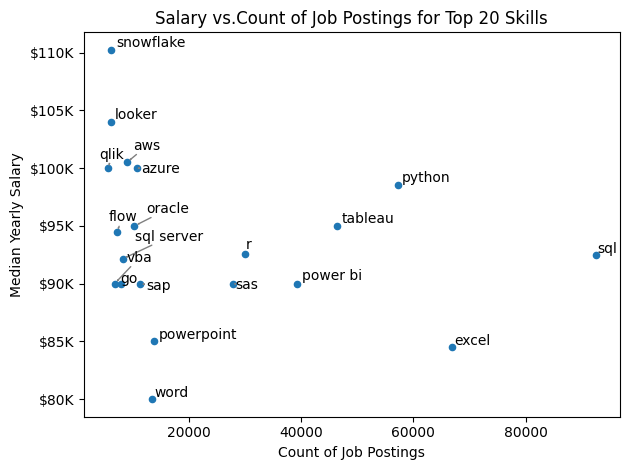

In [23]:
from adjustText import adjust_text
#fig,ax = plt.subplots()
skill_stats.plot(kind = 'scatter',x ='skill_count' ,y ='median_salary')

#Set axis lables,title and legend
plt.xlabel('Count of Job Postings')
plt.ylabel('Median Yearly Salary')
plt.title(f'Salary vs.Count of Job Postings for Top {skill_count} Skills')

texts =[]
for i,txt in enumerate(skill_stats.index):
    texts.append(plt.text(skill_stats['skill_count'].iloc[i],skill_stats['median_salary'].iloc[i],txt))

adjust_text(texts,arrowprops=dict(arrowstyle='->', color='gray'))

ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y,pos:f'${int(y/1000)}K'))


plt.tight_layout()
plt.show()